# Part 1 Heuristic Perceptron

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import csv, math

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

Loaded 100 points: 50 class-1 (blue), 50 class-0 (red)


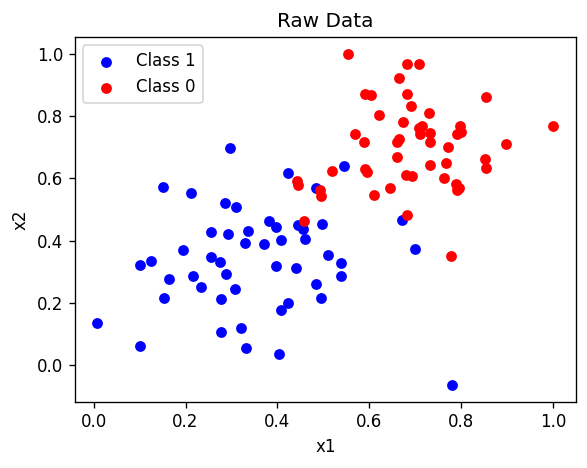

In [15]:
#Preliminary graph raw. 
#Just reading in data

def load_data(path):
    X, y = [], []
    with open(path) as f:
        for row in csv.reader(f):
            X.append([float(row[0]), float(row[1])])
            y.append(int(row[2]))
    return np.array(X), np.array(y)

import os
for candidate in ['data-1.csv', 'data.csv']:
    if os.path.exists(candidate):
        X, y = load_data(candidate)
        break
else:
    raise FileNotFoundError("data-1.csv not found. Place it in the same folder as this notebook.")

print(f'Loaded {len(X)} points: {sum(y==1)} class-1 (blue), {sum(y==0)} class-0 (red)')

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', s=30, label='Class 1')
ax.scatter(X[y==0, 0], X[y==0, 1], c='red',  s=30, label='Class 0')
ax.set_title('Raw Data'); ax.legend()
ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout()
display(fig)
plt.close(fig)

In [21]:
# Helper functions

def sigmoid(z):
    """Sigmoid activation: σ(z) = 1 / (1 + e^-z)"""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))



In [22]:
#4 
#Heuristic Perceptron Implementation
def perceptron_heuristic(X, y, learning_rate=0.1, max_iter=100, tol=1e-4, seed=42):
    rng = np.random.RandomState(seed)
    w1, w2, b = rng.randn(3) * 0.01

    history = [(w1, w2, b)]          

    for iteration in range(max_iter):
        total_err = 0.0
        for i in range(len(X)):
            x1, x2   = X[i]
            label    = y[i]
            z        = w1*x1 + w2*x2 + b
            y_hat    = sigmoid(z)       
            err      = label - y_hat    
            total_err += abs(err)

            # Weight update rule
            b  += learning_rate * err
            w1 += learning_rate * err * x1
            w2 += learning_rate * err * x2

        history.append((w1, w2, b))


    return history


def plot_heuristic(ax, history, learning_rate):
    plot_data(ax)

    # Initial boundary — RED
    xs, ys = boundary_line(*history[0])
    if xs is not None:
        ax.plot(xs, ys, 'r-', linewidth=1.5, label='Initial', zorder=4)


    for step in history[1:-1]:
        xs, ys = boundary_line(*step)
        if xs is not None:
            ax.plot(xs, ys, '--', color='green', alpha=0.35, linewidth=0.6)


    xs, ys = boundary_line(*history[-1])
    if xs is not None:
        ax.plot(xs, ys, 'k-', linewidth=2, label=f'Final (iter {len(history)-1})', zorder=6)

    ax.set_title(f'Solution boundary\nLR={learning_rate}, iters={len(history)-1}', fontsize=9)
    ax.legend(fontsize=7)

In [ ]:
#5
#Three Learning Rates

learning_rates_p1 = [0.01, 0.1, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Part 1 — Heuristic Perceptron', fontsize=13, fontweight='bold')

for ax, lr in zip(axes, learning_rates_p1):
    print(f'Learning rate = {lr}')
    hist = perceptron_heuristic(X, y, learning_rate=lr, max_iter=65)
    plot_heuristic(ax, hist, lr)

plt.tight_layout()
display(fig)
plt.close(fig)
plt.show()

Learning rate = 0.01
  Max iterations (65) reached, total|err|=30.7156
Learning rate = 0.1
  Max iterations (65) reached, total|err|=13.1711
Learning rate = 1.0
  Max iterations (65) reached, total|err|=7.4039


# Part 2 Gradient Descent

In [24]:
def log_loss(X, y, w1, w2, b):
    """Binary cross-entropy loss over the full dataset."""
    eps = 1e-15
    total = 0.0
    for i in range(len(X)):
        z = w1*X[i,0] + w2*X[i,1] + b
        p = float(np.clip(sigmoid(z), eps, 1 - eps))
        total += -(y[i]*math.log(p) + (1 - y[i])*math.log(1 - p))
    return total / len(X)


def perceptron_gradient_descent(X, y, learning_rate=0.1, epochs=100, seed=42):
    rng = np.random.RandomState(seed)
    w1, w2, b = rng.randn(3) * 0.01

    history    = [(w1, w2, b)]     
    err_epochs = []
    err_values = []

    for epoch in range(epochs):
        for i in range(len(X)):
            x1, x2     = X[i]
            true_label = y[i]
            z          = w1*x1 + w2*x2 + b
            predicted  = 1 if sigmoid(z) >= 0.5 else 0

            if predicted != true_label:           
                if predicted == 0:               
                    b  += learning_rate
                    w1 += learning_rate * x1
                    w2 += learning_rate * x2
                else:                             
                    b  -= learning_rate
                    w1 -= learning_rate * x1
                    w2 -= learning_rate * x2

        history.append((w1, w2, b))

        # Record log loss every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            loss = log_loss(X, y, w1, w2, b)
            err_epochs.append(epoch + 1)
            err_values.append(loss)

    return history, err_epochs, err_values


def plot_gd(ax_b, ax_e, history, err_epochs, err_values, lr, epochs):
    # ── Decision boundary plot ──
    plot_data(ax_b)

    xs, ys = boundary_line(*history[0])        
    if xs is not None:
        ax_b.plot(xs, ys, 'r-', linewidth=1.5, label='Initial', zorder=4)

    for step in history[1:-1]:                 
        xs, ys = boundary_line(*step)
        if xs is not None:
            ax_b.plot(xs, ys, '--', color='green', alpha=0.25, linewidth=0.5)

    xs, ys = boundary_line(*history[-1])       
    if xs is not None:
        ax_b.plot(xs, ys, 'k-', linewidth=2, label=f'Final (epoch {epochs})', zorder=6)

    ax_b.set_title(f'Solution boundary\nLR={lr}, epochs={epochs}', fontsize=9)
    ax_b.legend(fontsize=7)

    # ── Error plot ──
    ax_e.plot(err_epochs, err_values, color='steelblue', linewidth=2)
    ax_e.set_title(f'Error Plot\nLR={lr}, epochs={epochs}', fontsize=9)
    ax_e.set_xlabel('Number of epochs')
    ax_e.set_ylabel('Log Loss')
    ax_e.grid(True, alpha=0.3)

### Vary Learning Rate (100 epochs each)

In [ ]:
learning_rates_p2 = [0.01, 0.1, 1.0]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle('Part 2 — Gradient Descent (varying LR, 100 epochs)', fontsize=12, fontweight='bold')

for row, lr in enumerate(learning_rates_p2):
    print(f'LR={lr}, epochs=100')
    hist, err_ep, err_val = perceptron_gradient_descent(X, y, learning_rate=lr, epochs=100)
    print(f'  Final log loss = {err_val[-1]:.4f}')
    plot_gd(axes[row, 0], axes[row, 1], hist, err_ep, err_val, lr, 100)

plt.tight_layout()
display(fig)
plt.close(fig)

LR=0.01, epochs=100
  Final log loss = 0.6803
LR=0.1, epochs=100
  Final log loss = 0.5766
LR=1.0, epochs=100
  Final log loss = 0.3785


### Vary Epochs (LR = 0.1)

In [ ]:
epoch_list = [10, 100, 500]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle('Part 2 — Gradient Descent (LR=0.1, varying epochs)', fontsize=12, fontweight='bold')

for row, ep in enumerate(epoch_list):
    print(f'LR=0.1, epochs={ep}')
    hist, err_ep, err_val = perceptron_gradient_descent(X, y, learning_rate=0.1, epochs=ep)
    print(f'  Final log loss = {err_val[-1]:.4f}')
    plot_gd(axes[row, 0], axes[row, 1], hist, err_ep, err_val, 0.1, ep)

plt.tight_layout()
display(fig)
plt.close(fig)

LR=0.1, epochs=10
  Final log loss = 0.6503
LR=0.1, epochs=100
  Final log loss = 0.5766
LR=0.1, epochs=500
  Final log loss = 0.5522
